In [1]:
import os
import numpy as np
import pyvista as pv
import pandas as pd
import matplotlib.pyplot as plt
import re

In [2]:
# Set the font family and size to use for Matplotlib figures.
plt.rcParams['font.size'] = 17
np.set_printoptions(precision=16)
pd.set_option("display.precision", 16)

In [3]:
pd.set_option("display.precision", 16)

In [4]:
# missing solver tolerance study 
df0 = pd.read_csv('tabular1.dat', delim_whitespace=True) # initial study with mesh and time study (<0.1sec)
df1  = pd.read_csv('tabular_timeStudy_new.dat', delim_whitespace=True) # time study fixed mesh 3
df2 = pd.read_csv('tabular_timeStudy_new2.dat', delim_whitespace=True) # time and mesh variability study newest
df3 = pd.read_csv('tabular_meshStudy.dat',delim_whitespace=True) # mesh study, duration = 12 sec timestep = 0.005
df4 = pd.read_csv('tabular_meshTimeAll.dat', delim_whitespace=True)
df5 = pd.read_csv('tabular_largeTimes.dat', delim_whitespace=True)
# df = pd.read_csv('tabular_timeStudy.dat', delim_whitespace=True) # this was using the courrant number 
df6 = pd.read_csv('tabular_solvTol.dat', delim_whitespace=True)
## These are mesh vs time changes x2 or x8 
df7 = pd.read_csv('tabular_timevsmeshx2.dat', delim_whitespace=True) 
df8 = pd.read_csv('tabular_timevsmeshx8.dat', delim_whitespace=True) 


df = pd.concat([df0,df1,df2,df3,df4,df5,df6,df7,df8])
df = df.reset_index()
df
# df['t2_r2']

,index,%eval_id,interface,mesh_size,num_processors,time_step,write_interval,duration,tol,t0.01_r2,...,t4_r2,t4.5_r2,t5_r2,t6_r2,t7_r2,t8_r2,t9_r2,t10_r2,t11_r2,t12_r2
0,0,1,NO_ID,0,3,0.005000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,NO_ID,1,3,0.005000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,3,NO_ID,2,5,0.005000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,4,NO_ID,3,9,0.005000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,5,NO_ID,4,18,0.005000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,6,NO_ID,5,18,0.005000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,7,NO_ID,2,5,0.002000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,8,NO_ID,2,9,0.001000,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,9,NO_ID,2,18,0.000500,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,10,NO_ID,2,36,0.000250,0.01,0.1,0.00000100,292.1499939000000268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
time_step = df['time_step']
mesh_num = df['mesh_size']
solv_tol = df['tol']
time = []
i = 0
while i <len(df[:]):
    time_i = np.arange(df['write_interval'][i],df['duration'][i]+df['write_interval'][i],df['write_interval'][i])
    time.append(time_i)
    i+=1
time[11:15]

[array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ]),
 array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])]

In [6]:
# All indices

# df.columns[9:]
# index_prelim = np.arange(9,19,1)   #0.01 to 0.1 sec by 0.01
# index_time   = np.arange(19,29,1)  #0.5 to 5sec by 0.5 sec
# index_mesh   = [20,22,24,26,28,29,30,31,32,33,34,35] #1 to 12 by 1sec
index_mesh5   = [20,22,24,26,28] #1 to 5 by 1sec

In [7]:
def columnNames(index_type):
    columnNames_study  = []
    for index in index_type:
        columnNames_study.append(df.columns[index])
    return columnNames_study
# columnNames = df.columns[9:] #[8:]

In [8]:
index_meshTime = [45,52] #[35,36,37,38,32,33,34]
# index for mesh and time variability 23
time_mesh5 = [1,2,3,4,5]
columnNames_meshTime = columnNames(index_mesh5)

In [9]:
#index for diagonal study 
index_diagonal = [20,19,18,24,25,26,27] # (mesh,time) 17 after
time_mesh5 = [1,2,3,4,5]
columnNames_mesh5 = columnNames(index_mesh5)

In [10]:
mesh_elem = ['0','8486','18370','36516','69736','145152','295981','578733']#,'1200000']
mesh_num = mesh_elem[1:]

## Study - Mesh 

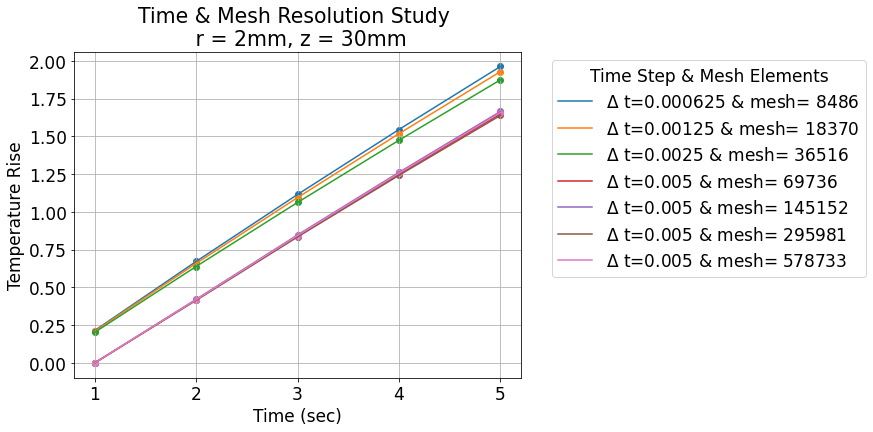

In [11]:
plt.figure(figsize=(8,6))
plt.title('Time & Mesh Resolution Study \n r = 2mm, z = 30mm');
plt.xlabel('Time (sec)');
plt.ylabel('Temperature Rise');
plt.grid(True, which="both",ls='-');
i =  0 
for f in index_diagonal:
    plt.plot(time_mesh5,(df.iloc[f][columnNames_mesh5])-300,label=f'$\Delta$ t={time_step[f]} & mesh= {mesh_num[i]}');
    plt.scatter(time_mesh5,(df.iloc[f][columnNames_mesh5])-300);
    i +=1
plt.legend(title='Time Step & Mesh Elements', bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studyTimeMeshResolution_1.png', dpi = 300, bbox_inches='tight')

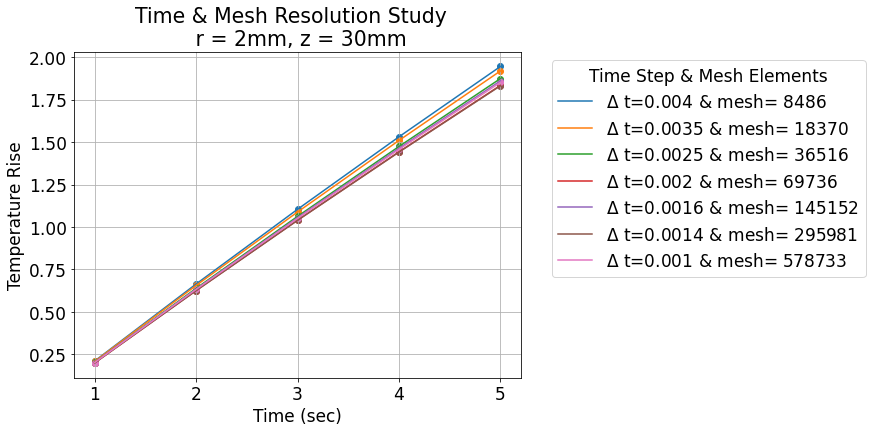

In [12]:
plt.figure(figsize=(8,6))
plt.title('Time & Mesh Resolution Study  \n r = 2mm, z = 30mm');
plt.xlabel('Time (sec)');
plt.ylabel('Temperature Rise');
plt.grid(True, which="both",ls='-');
i = 0 
for f in np.arange(45,52): #index_meshTime:
    plt.plot(time_mesh5,(df.iloc[f][columnNames_meshTime])-300,label=f'$\Delta$ t={time_step[f]} & mesh= {mesh_num[i]}');
    plt.scatter(time_mesh5,(df.iloc[f][columnNames_meshTime])-300);
    i+=1
# plt.ylim(300,302.5)
plt.legend(title='Time Step & Mesh Elements', bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studyTimeMeshResolution_3.png', dpi = 300, bbox_inches='tight')

# Calculate the relative error in this case!!!!!!!

In [13]:
#### Try this with Grid Convergence Index 

[0.2106628000000228, 0.20849609999999075, 0.20239259999999604, 0.19967650000000958, 0.20208739999998215, 0.19934080000001586, 0.2016906999999719]
[0.664276099999995, 0.6557007000000112, 0.6387023999999997, 0.6260376000000178, 0.6340026999999964, 0.6250916000000188, 0.6324157999999898]
[1.1044312000000218, 1.0884399000000258, 1.062713599999995, 1.0404052999999749, 1.0552979000000278, 1.0393371999999772, 1.0509033000000159]
[1.5315246999999772, 1.510101299999974, 1.4745482999999808, 1.4431152000000225, 1.4639892999999802, 1.4413452000000007, 1.457458499999973]
[1.9458923000000254, 1.9195556999999894, 1.8746032999999898, 1.8345947000000251, 1.8612671000000205, 1.8319397000000208, 1.8522644000000241]


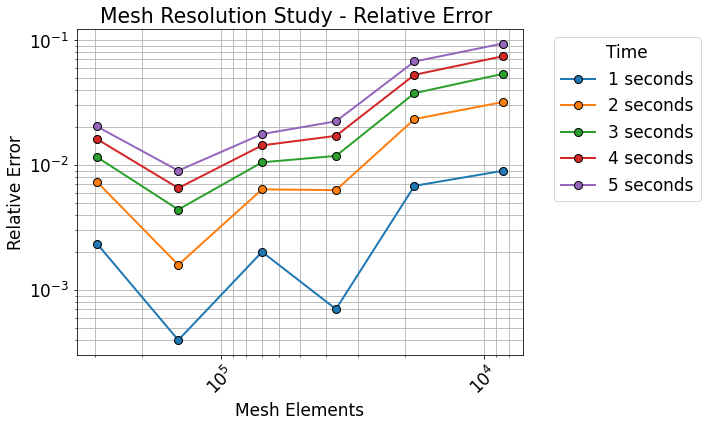

In [14]:
plt.figure(figsize=(8,6)) 
plt.title(f'Mesh Resolution Study - Relative Error '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('Mesh Elements')
plt.ylabel('Relative Error');
plt.grid(True, which="both",ls='-');
for i in np.arange(0,5):   #12):
    qoi = []
    meshElem_qoi = []
    for f in np.arange(45,52): #index_meshTime:
        qoi.append((df.iloc[f][columnNames_meshTime[i]])-300)
    print(qoi)
    mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
    plt.loglog(mesh_elem[:-1], np.abs(qoi[:-1]-qoi[-1]),marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i+1} seconds');
plt.xticks(rotation=45)
plt.legend(title='Time', bbox_to_anchor=(1.05,1.0))
#     plt.xlim(8000,)
plt.gca().invert_xaxis()  # For reversing the x-axis
#     plt.ylim(rangeMin[i],rangeMax[i])
plt.savefig(f'figures/studyMeshTimeResolution-RelativeError.png', dpi = 300, bbox_inches='tight')

In [22]:
qoiAll = [];
qoiAllDiff =[]
for i in np.arange(0,5):   #12):
    qoi = []
    for f in np.arange(45,52):
        qoi.append((df.iloc[f][columnNames_meshTime[i]])-300)
    qoiAll.append(qoi)
    #qoiAllDiff.append(100*np.abs(qoi[:-1]-qoi[-1])/((qoi[:-1]+qoi[-1])/2))
    qoiAllDiff.append(np.abs(qoi[:-1]-qoi[-1]))
len(qoiAll)

qoi_percent_meshTime = []
for i in np.arange(0,5):
    for j in np.arange(0,6):
        if j == 3:
            qoi_percent_meshTime.append(qoiAllDiff[i][j]) 

mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
np.max(qoi_percent_meshTime)*100

1.7669699999999011

In [23]:
qoi_percent_meshTime

[0.0020141999999623295,
 0.006378199999971912,
 0.010498000000040975,
 0.014343299999950432,
 0.01766969999999901]

ValueError: The number of FixedLocator locations (8), usually from a call to set_ticks, does not match the number of ticklabels (7).

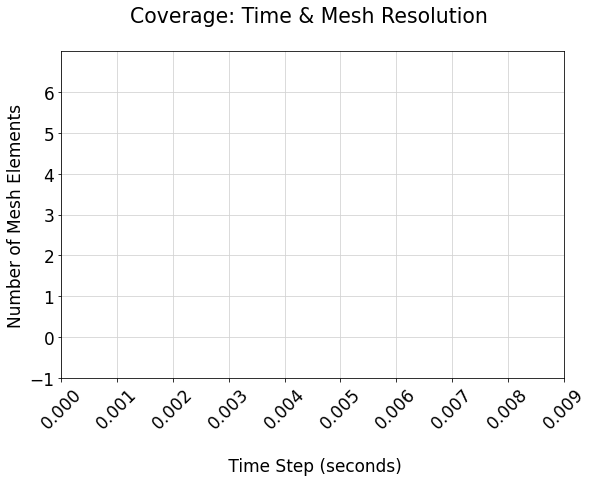

In [24]:
# Coverage of Study 
plt.figure(figsize=(9,6));
plt.title('Coverage: Time & Mesh Resolution \n');
plt.xlabel('\n Time Step (seconds)');
plt.ylabel('Number of Mesh Elements');
plt.grid(True, which="both",ls='-', color='lightgray');
plt.xlim(0.0, 0.009);
plt.xticks(rotation=45);
plt.ylim(0,7);
plt.yticks(ticks=[-1,0,1,2,3,4,5,6], labels=mesh_elem);
plt.scatter(df['time_step'], df['mesh_size'], marker='x',color='green')#,alpha=0.5, cmap='viridis')
plt.savefig(f'figures/coverageTimeMesh.png', dpi = 300, bbox_inches='tight')

In [25]:
index_mesh12   = [20,22,24,26,28,29,30,31,32,33,34,35] #1 to 12 by 1sec
columnNames_mesh12 = columnNames(index_mesh12)
time = np.arange(1,13,1)
# columnNames_mesh12

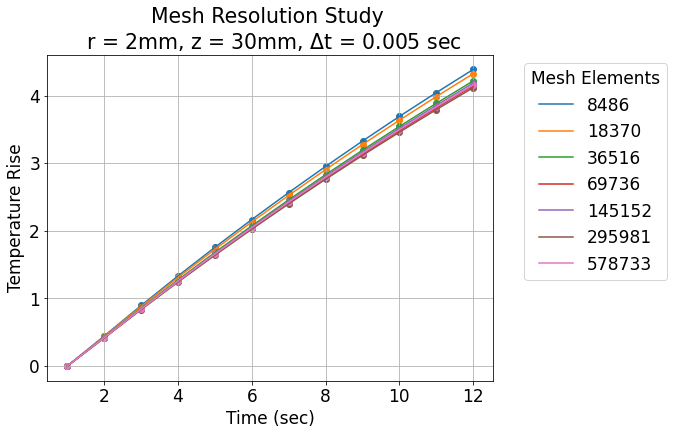

In [26]:
plt.figure(figsize=(8,6))
plt.title('Mesh Resolution Study \n r = 2mm, z = 30mm, $\Delta$t = 0.005 sec');
plt.xlabel('Time (sec)');
plt.ylabel('Temperature Rise');
plt.grid(True, which="both",ls='-');
i = 0 
for f in np.arange(21,28):
    plt.plot(time,(df.iloc[f][columnNames_mesh12])-300,label=f'{mesh_num[i]}');
    plt.scatter(time,(df.iloc[f][columnNames_mesh12])-300);
    i+=1
plt.legend(title='Time Step', bbox_to_anchor=(1.05,1.0))
plt.legend(title='Mesh Elements', bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studyMeshResolution_t0.005.png', dpi = 300, bbox_inches='tight')

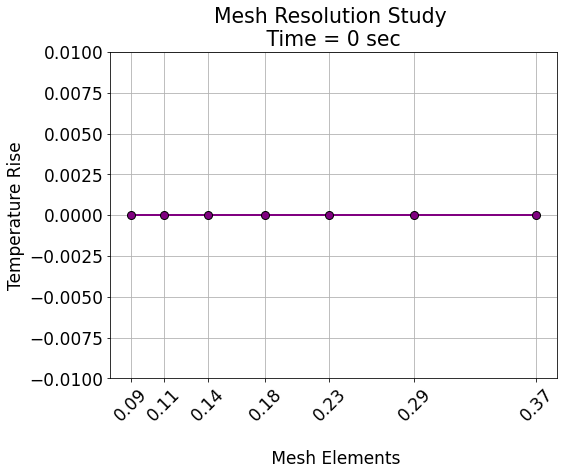

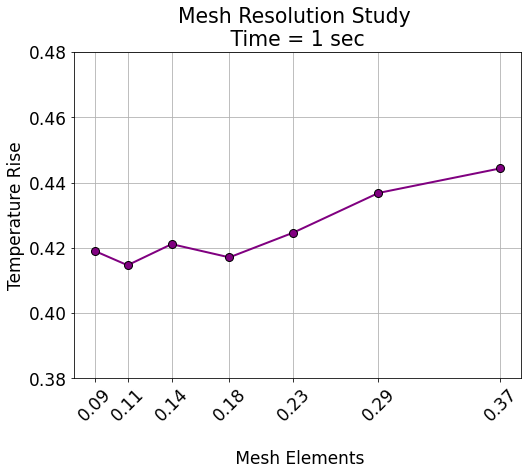

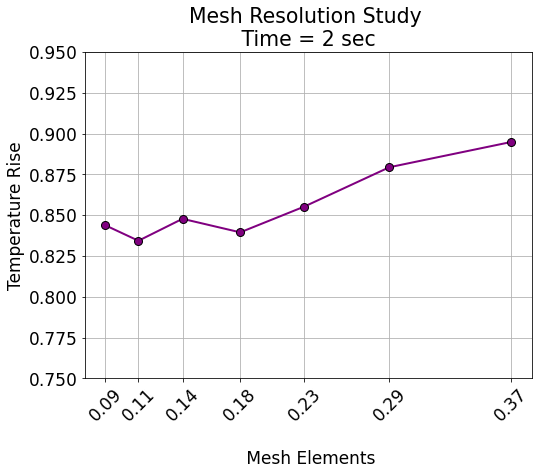

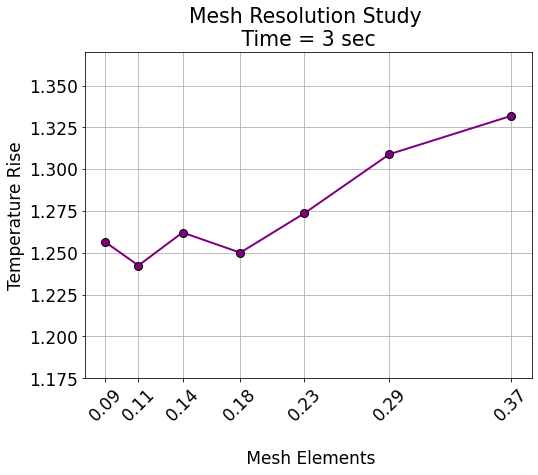

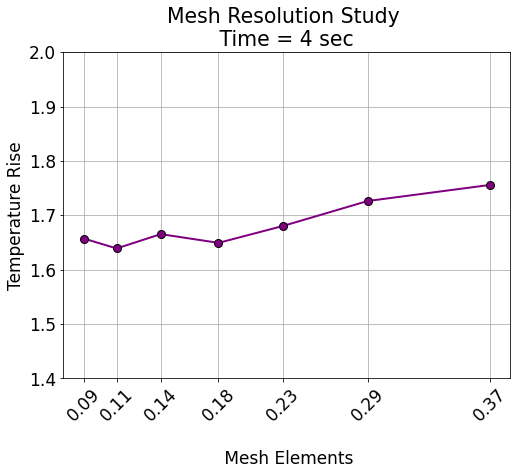

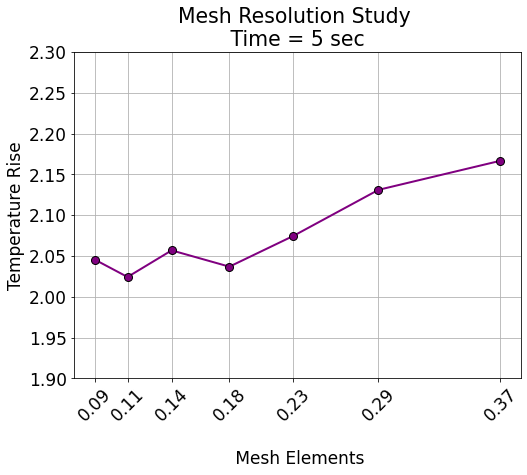

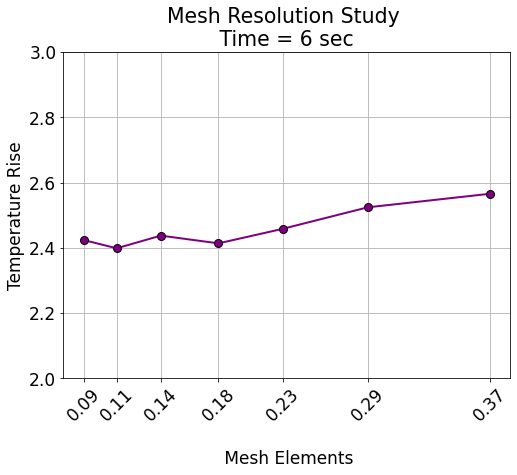

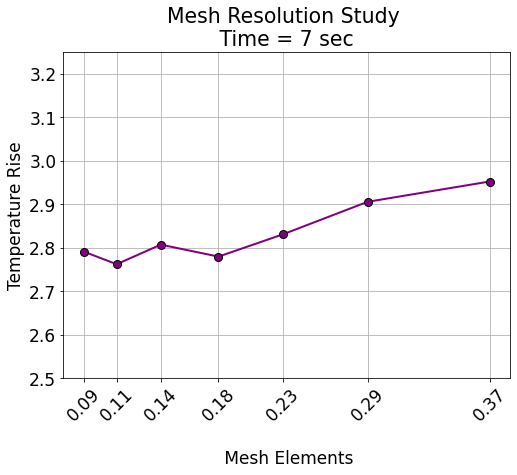

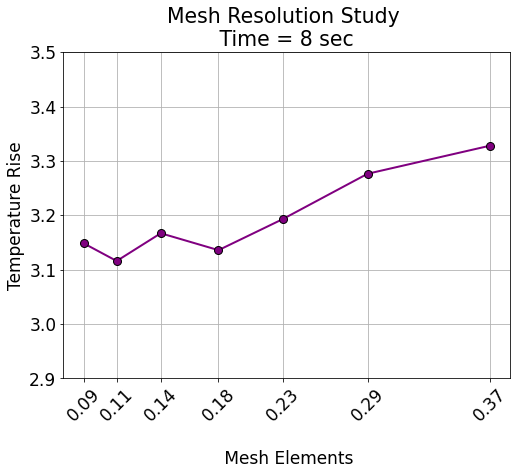

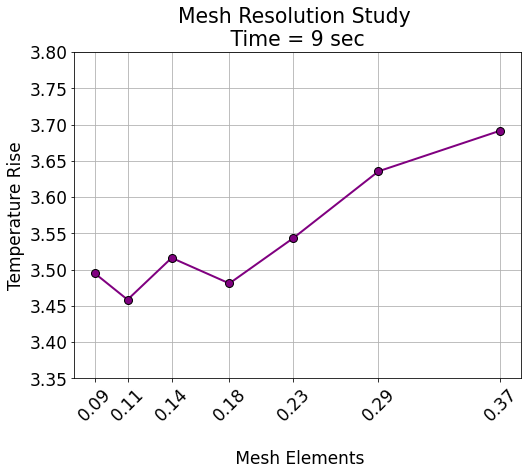

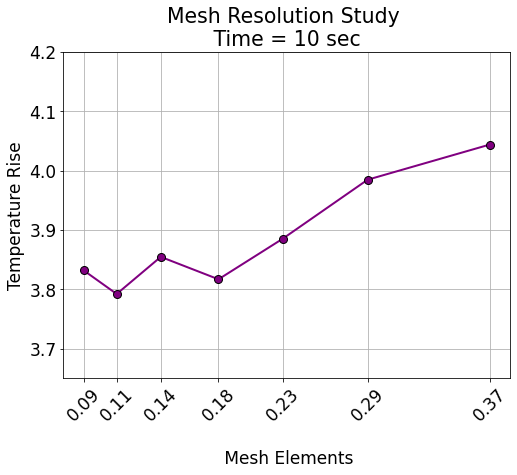

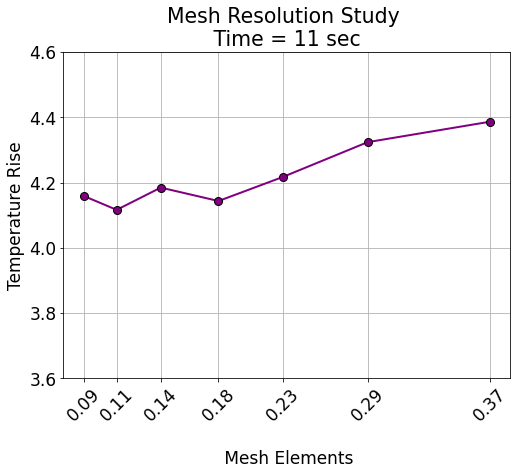

In [59]:
rangeMin = [-0.01,0.38,0.75,1.175,1.40,1.90,2.0,2.50,2.9,3.35,3.65,3.6]
rangeMax = [ 0.01,0.48,0.95,1.370,2.00,2.30,3.0,3.25,3.50,3.80,4.20,4.60]
for i in np.arange(0,12):
    plt.figure(figsize=(8,6)) 
    plt.title(f'Mesh Resolution Study \n Time = {i} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
    plt.xlabel('\n Mesh Elements');
    plt.ylabel('Temperature Rise');
    plt.grid(True, which="both",ls='-');
    qoi = []
    meshElem_qoi = []
    for f in np.arange(21,28):
        qoi.append((df.iloc[f][columnNames_mesh12[i]])-300)
    mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
    #     plt.xlim(8000,)
#     plt.gca().invert_xaxis()  # For reversing the x-axis
    plt.ylim(rangeMin[i],rangeMax[i])
    plt.plot(len_representative, qoi, color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
    plt.xticks(len_representative, ['{:.2f}'.format(rep) for rep in len_representative], rotation=45);
    plt.tick_params(axis='x',which='minor',labelbottom=False)
#     plt.grid(which='both',linestyle='--',linedwidth=0.5)
    plt.grid(True)
    plt.savefig(f'../analysis_postprocessing/figures/studyMeshResolution_time{i}_Manuscript.png', dpi = 300, bbox_inches='tight')

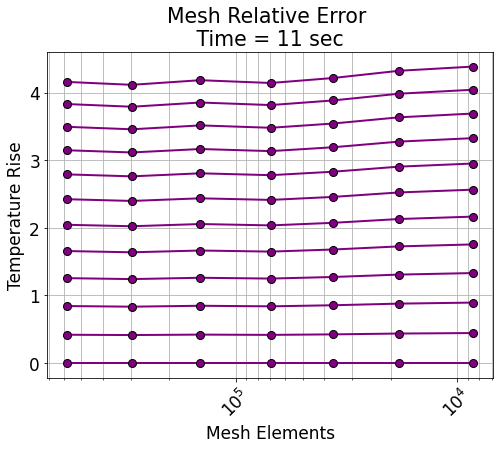

In [28]:
# rangeMin = [-0.01,0.38,0.75,1.175,1.40,1.90,2.0,2.50,2.9,3.35,3.65,3.6]
# rangeMax = [ 0.01,0.48,0.95,1.370,2.00,2.30,3.0,3.25,3.50,3.80,4.20,4.60]
plt.figure(figsize=(8,6)) 
plt.title(f'Mesh Relative Error \n Time = {i} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('Mesh Elements');
plt.ylabel('Temperature Rise');
plt.grid(True, which="both",ls='-');
for i in np.arange(0,12):
    qoi = []
    meshElem_qoi = []
    for f in np.arange(21,28):
        qoi.append((df.iloc[f][columnNames_mesh12[i]])-300)
    mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
    plt.semilogx(mesh_elem, qoi, color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
plt.xticks(rotation=45);
#     plt.xlim(8000,)
plt.gca().invert_xaxis()  # For reversing the x-axis
# plt.ylim(rangeMin[i],rangeMax[i])
# plt.savefig(f'figures/studyMeshResolution_time{i}.png', dpi = 300, bbox_inches='tight')

In [29]:
# Geometry Volume

mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
vol_pipe = 418.708499 #mm * 0.001 # Meters
case_vol = 16.421687 #mm * 0.001  # Meters
total_vol = vol_pipe + case_vol # Meters
edds_volume = total_vol #3911.381 # mm
len_representative = (edds_volume / np.array(mesh_elem))**(1/3)

In [78]:
np.abs(qoi[:-2]-qoi[-1])

array([0.2274474999999825, 0.1649170000000026, 0.0579528999999752,
       0.0155029000000013, 0.0256652999999574])

/tmp/ipykernel_159595/1094423262.py:15: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xticks(rotation=45);


[0. 0. 0. 0. 0. 0.]
[0.0252990999999838 0.0177611999999954 0.0056151999999656
 0.0019837000000393 0.0020751999999788 0.0043944999999894]
[0.0511475000000132 0.0356445000000463 0.0115357000000245
 0.0042723999999907 0.0040283000000159 0.0094298999999864]
[0.0755615000000489 0.0525818000000413 0.0172729000000231
 0.0062560999999732 0.0057983000000377 0.013946599999997 ]
[0.0985108000000423 0.0690003000000274 0.0228882000000112
 0.0079650999999785 0.0081177000000139 0.0182189999999878]
[0.1211243000000195 0.0854491999999709 0.0290221999999858
 0.008758499999999  0.0112305000000106 0.0214232999999808]
[0.1417541000000142 0.100250200000005  0.0343017000000145
 0.0101624000000129 0.013580300000001  0.0252990999999838]
[0.1611632999999983 0.1145325000000526 0.0394287000000304
 0.0114745999999855 0.0160523000000126 0.0289916999999491]
[0.179473900000005  0.1280213000000003 0.0444335999999907
 0.01254270000004   0.0185851999999613 0.032470700000033 ]
[0.1967468999999937 0.1405944999999633 0.048

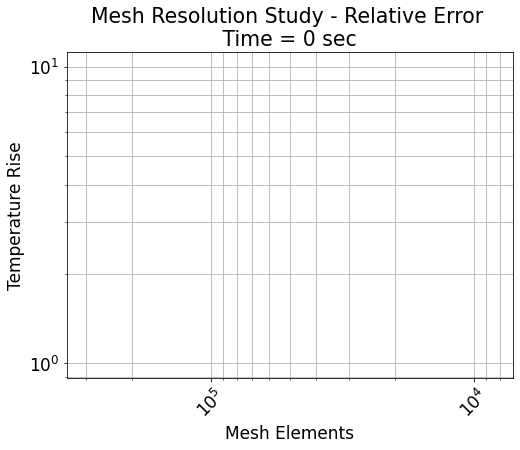

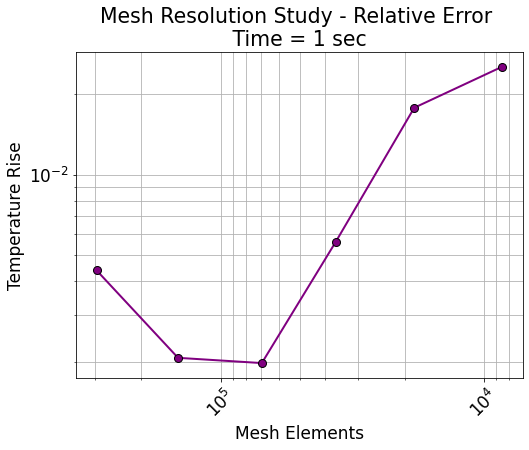

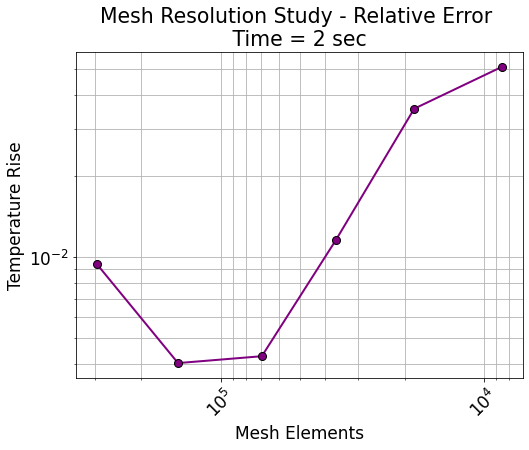

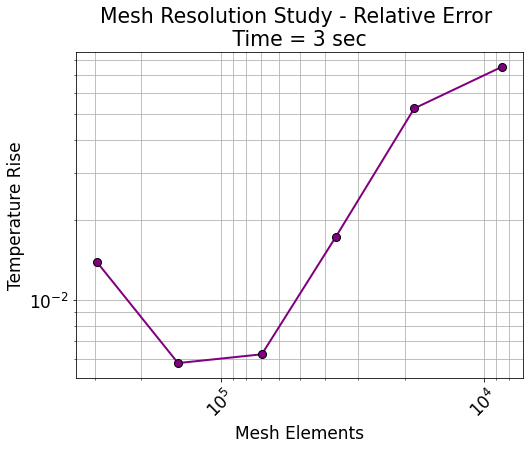

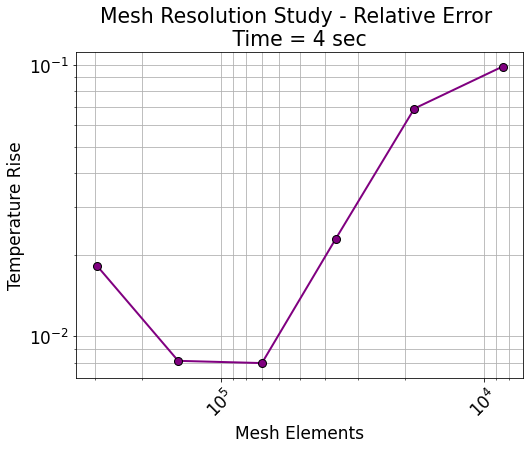

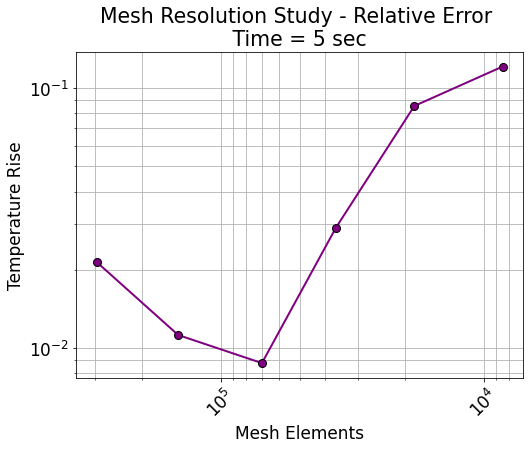

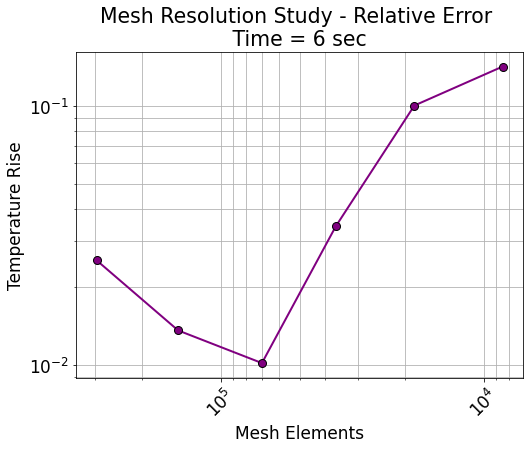

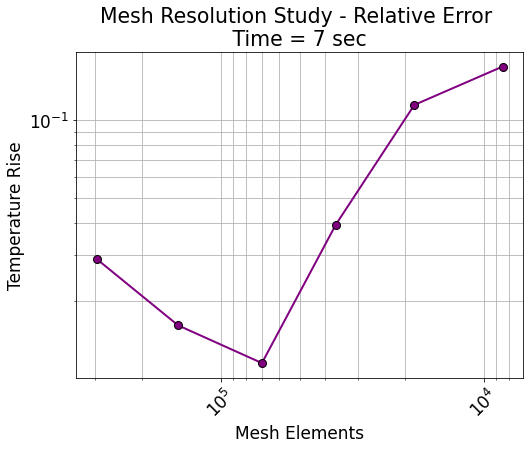

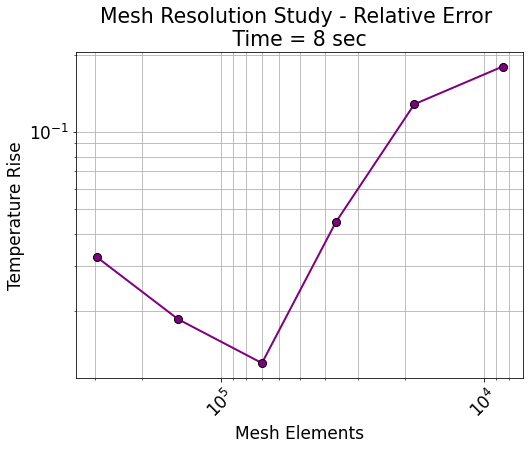

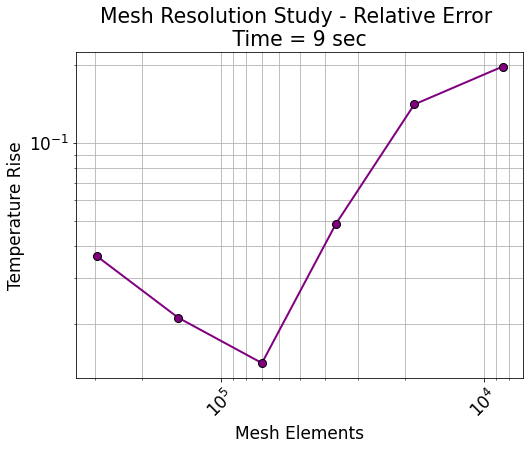

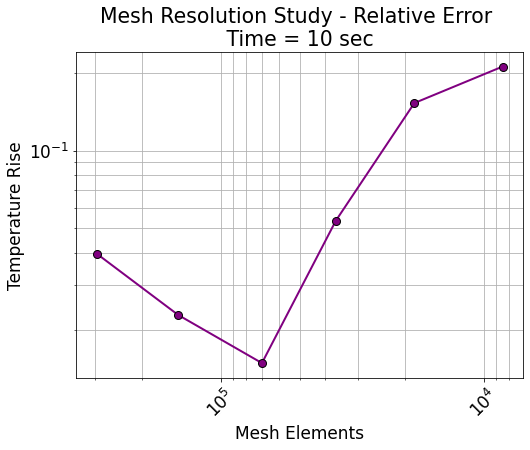

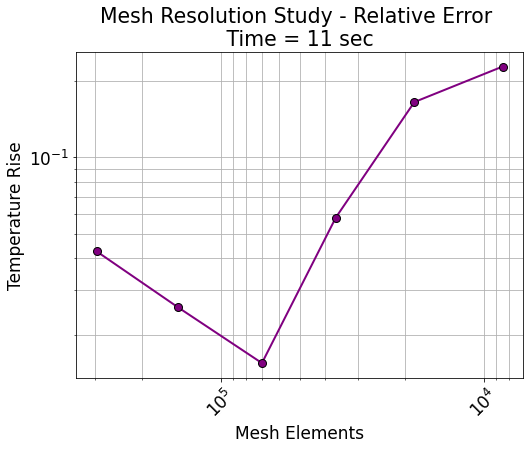

In [79]:
# rangeMin = [-0.01,0.38,0.75,1.175,1.40,1.90,2.0,2.50,2.9,3.35,3.65,3.6]
# rangeMax = [ 0.01,0.48,0.95,1.370,2.00,2.30,3.0,3.25,3.50,3.80,4.20,4.60]
for i in np.arange(0,12):
    plt.figure(figsize=(8,6)) 
    plt.title(f'Mesh Resolution Study - Relative Error \n Time = {i} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
    plt.xlabel('Mesh Elements');
    plt.ylabel('Temperature Rise');
    plt.grid(True, which="both",ls='-');
    qoi = []
    meshElem_qoi = []
    for f in np.arange(21,28):
        qoi.append((df.iloc[f][columnNames_mesh12[i]])-300)
    mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
    plt.loglog(mesh_elem[:-1], np.abs(qoi[:-1]-qoi[-1]), color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
    plt.xticks(rotation=45);
#     plt.xlim(8000,)
    plt.gca().invert_xaxis()  # For reversing the x-axis
#     plt.ylim(rangeMin[i],rangeMax[i])
    plt.savefig(f'figures/studyMeshResolution-RelativeError_time{i}.png', dpi = 300, bbox_inches='tight')
    print(np.abs(qoi[:-1]-qoi[-1]))

In [80]:
# [0. 0. 0. 0. 0. 0.]
# [0.0252990999999838 0.0177611999999954 0.0056151999999656 0.0019837000000393 0.0020751999999788 0.0043944999999894]
# [0.0511475000000132 0.0356445000000463 0.0115357000000245 0.0042723999999907 0.0040283000000159 0.0094298999999864]
# [0.0755615000000489 0.0525818000000413 0.0172729000000231 0.0062560999999732 0.0057983000000377 0.013946599999997 ]
# [0.0985108000000423 0.0690003000000274 0.0228882000000112 0.0079650999999785 0.0081177000000139 0.0182189999999878]
# [0.1211243000000195 0.0854491999999709 0.0290221999999858 0.008758499999999  0.0112305000000106 0.0214232999999808]
# [0.1417541000000142 0.100250200000005  0.0343017000000145 0.0101624000000129 0.013580300000001  0.0252990999999838]
# [0.1611632999999983 0.1145325000000526 0.0394287000000304 0.0114745999999855 0.0160523000000126 0.0289916999999491]
# [0.179473900000005  0.1280213000000003 0.0444335999999907 0.01254270000004   0.0185851999999613 0.032470700000033 ]
# [0.1967468999999937 0.1405944999999633 0.0486144999999851 0.0141296000000466 0.0211486999999693 0.0365295000000287]
# [0.2121887000000129 0.1530151000000046 0.0533446999999683 0.014892599999996  0.0229186999999911 0.0396729000000278]
# [0.2274474999999825 0.1649170000000026 0.0579528999999752 0.0155029000000013 0.0256652999999574 0.0426025000000436]

In [84]:
qoiAll = [];
qoiAllDiff =[]
for i in np.arange(1,12):   #12):
    qoi = []
    for f in np.arange(21,28):
        qoi.append((df.iloc[f][columnNames_mesh12[i]])-300)
    qoiAll.append(qoi)
    #qoiAllDiff.append(100*np.abs(qoi[:-1]-qoi[-1])/((qoi[:-1]+qoi[-1])/2))
    qoiAllDiff.append(np.abs(qoi[:-1]-qoi[-1]))
len(qoiAll)

qoi_percent_mesh3 = []
for i in np.arange(0,11):
    for j in np.arange(0,6):
        if j == 2:
            qoi_percent_mesh3.append(qoiAllDiff[i][j])    
np.max(qoi_percent_mesh3)*100


5.795289999997522

In [85]:
qoiAllDiff[3]

array([0.0985108000000423, 0.0690003000000274, 0.0228882000000112,
       0.0079650999999785, 0.0081177000000139, 0.0182189999999878])

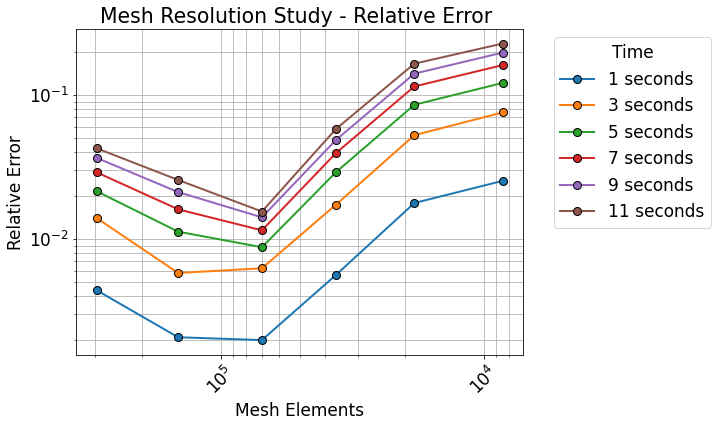

In [86]:
# rangeMin = [-0.01,0.38,0.75,1.175,1.40,1.90,2.0,2.50,2.9,3.35,3.65,3.6]
# rangeMax = [ 0.01,0.48,0.95,1.370,2.00,2.30,3.0,3.25,3.50,3.80,4.20,4.60]
plt.figure(figsize=(8,6)) 
plt.title(f'Mesh Resolution Study - Relative Error '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('Mesh Elements')
plt.ylabel('Relative Error');
plt.grid(True, which="both",ls='-');
for i in np.arange(1,12):   #12):
    if np.mod(i, 2) != 0:   # odd only 
        qoi = []
        meshElem_qoi = []
        for f in np.arange(21,28):
            qoi.append((df.iloc[f][columnNames_mesh12[i]])-300)
        mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
        plt.loglog(mesh_elem[:-1], np.abs(qoi[:-1]-qoi[-1]),marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i} seconds');
plt.xticks(rotation=45)
plt.legend(title='Time', bbox_to_anchor=(1.05,1.0))
#     plt.xlim(8000,)
plt.gca().invert_xaxis()  # For reversing the x-axis
#     plt.ylim(rangeMin[i],rangeMax[i])
plt.savefig(f'figures/studyMeshResolution-RelativeError_timeODD.png', dpi = 300, bbox_inches='tight')
# print(np.abs(qoi[:-1]-qoi[-1]))

In [87]:
# qoiAll =  11 (time) x 7 (meshes) 
# mesh_elem = [m1,m2,m3,m4,m5,m6,m7]

In [88]:
# Geometry Volume
vol_pipe = 418.708499 #mm * 0.001 # Meters
case_vol = 16.421687 #mm * 0.001  # Meters
total_vol = vol_pipe + case_vol # Meters
edds_volume = total_vol #3911.381 # mm
len_representative = (edds_volume / np.array(mesh_elem))**(1/3)
mesh1,mesh2,mesh3 = mesh_elem[0],mesh_elem[3],mesh_elem[6]  
#------------
h3 = (edds_volume/mesh1    )#**(1/3)
h2 = (edds_volume/mesh2   )#**(1/3)
h1 = (edds_volume/mesh3  )#**(1/3)
#------------
r21 = h2/h1
r32 = h3/h2
srq3,srq2,srq1,e32,e21,s = [],[],[],[],[],[]   
for i in np.arange(0,11):   #12):
    #------------
    qoi_t = qoiAll[i]  # Time = i seconds 
    srq3_t = qoi_t[0]  #maxmeshrefinement1mm[1] # Mesh2
    srq2_t = qoi_t[3]  #maxmeshrefinement1mm[6] # Mesh3
    srq1_t = qoi_t[6]  #maxmeshrefinement1mm[9] # Mesh4_3
    e32_t  = srq3_t - srq2_t
    e21_t  = srq2_t - srq1_t
    s_t    = np.sign(e32_t/e21_t)
    srq3.append(srq3_t)
    srq2.append(srq2_t)
    srq1.append(srq1_t)
    e32 .append(e32_t)
    e21 .append(e21_t)
    s   .append(s_t)

In [89]:
### Calculate the Observed Order of Convervgence based on ASME V&V 20 (2-4.1 pg 13)
def f1(q_p, e32, e21, r21):
    return (1/np.log(r21))*np.log(np.abs(e32/e21)) + q_p

def f2(p, r21, r32, s):
    return np.log(((r21**p) - s)/((r32**p) - s))

def f3(e32, e21):
    return np.sign(e32/e21)
# Initial guess
q_p0 = 0
# Fixed-point iteration @ all times
p_times = []
for i in np.arange(0,11):   
    p = f1(q_p0,e32[i],e21[i],r21)
    for _ in range(100):  # Maximum number of iterations
        q_p = f2(p, r21, r32, s[i])
        p_new = f1(q_p, e32[i], e21[i], r21)
        if abs(p_new - p) < 1e-6:  # Convergence criterion
            break
        p = p_new
    p_times.append(p)

# Print the result
print("Observed p = ", p_times)

Observed p =  [1.250188444706202, 1.2222278857751923, 1.226131980702492, 1.2366005598225476, 1.2861672636013364, 1.2900025475513888, 1.2930713483737437, 1.3013750664470094, 1.2892211994438207, 1.2994645663985716, 1.3125471691673603]


In [90]:
##### Grid Convergence Index (GCI)
# Extrapolated Value used for Error Estimation 
srq_extrap_times = []
e21a_times = []
e21_extrap_times = []
for i in np.arange(0,11):   #12):
    srq_extrap = ((r21**p_times[i])*srq1[i] - srq2[i])/((r21**p_times[i]) -1) # Extrapolated SRQ
    e21a = np.abs(srq1[i]-srq2[i])
    e21extrapolated = np.abs((srq_extrap-srq1[i])/(srq_extrap))
    srq_extrap_times.append(srq_extrap)
    e21a_times      .append(e21a)
    e21_extrap_times.append(e21extrapolated)

In [91]:
errCGI3 = np.abs(srq3 - srq_extrap)
errCGI2 = np.abs(srq2 - srq_extrap)
errCGI1 = np.abs(srq1 - srq_extrap)
errCGI = np.array([errCGI1,errCGI2,errCGI3])
# errCGI

In [92]:
def richardson_extrapolation(errors0,errors1,element_sizes0, order):
    k = 2 
    m = order  
    richardson_extrapo = (k**m * errors1 - errors0) / (k**m - 1)
    richardson_element_size = element_sizes0 / k
    return richardson_extrapo, richardson_element_size

# srq = np.array([0.98303032,0.96357489,0.9016487]) # not errors but the SRQ Vel
srq = np.array([srq1,srq2,srq3])
# element_sizes = np.array([13328905, 3993266, 1723087 ])
element_sizes = np.array([h1,h2,h3])
order_of_convergence = p_times
rich_extrap_time, rich_elem_size_time = [],[]

for i in np.arange(0,11):   #12):
    rich_extrap, rich_elem_size = richardson_extrapolation(srq1[i],srq2[i],h3,p_times[i])
    rich_extrap_time.append(rich_extrap)
    rich_elem_size_time.append(rich_elem_size*total_vol)

print("Richardson extrapolation:", rich_extrap_time)
print("Element size for the extrapolated estimate:", rich_elem_size_time)

Richardson extrapolation: [0.4156449068271496, 0.8363031603853892, 1.2454512400358786, 1.6432977785272633, 2.0308389055802607, 2.4067258834346297, 2.771965866166383, 3.1271785070019122, 3.471110693431702, 3.806795287644619, 4.13313707147178]
Element size for the extrapolated estimate: [11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615, 11.155920266815615]


In [93]:
np.array(srq3) - np.array(srq_extrap_times)

array([0.0251475713755905, 0.0507996325787038, 0.0750566448969654,
       0.0978832240595846, 0.12050776475437  , 0.1410449261502391,
       0.1603680978230315, 0.1786208473713171, 0.1957591329715198,
       0.2111714427855196, 0.2264193871921298])

In [94]:
# rich_extrap_time
# srq_extrap_times

In [95]:
len_representative = np.array([float(f"{x:.2g}") for x in len_representative])

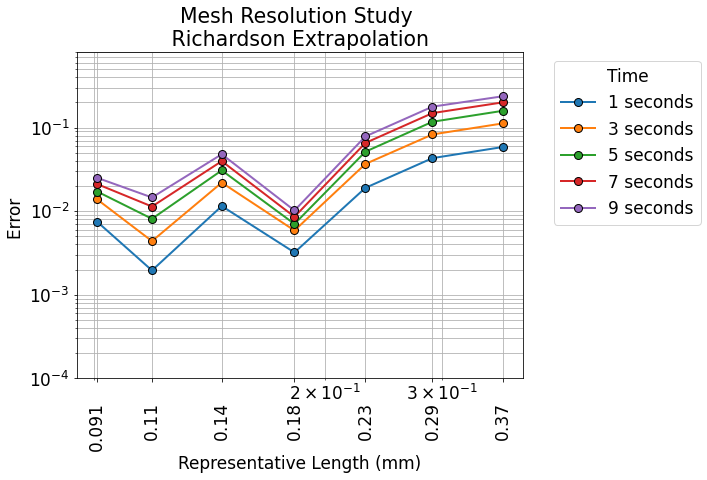

In [96]:
plt.figure(figsize=(8,6)) 
plt.title(f'Mesh Resolution Study \n Richardson Extrapolation '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('Representative Length (mm)')#Mesh Elements')
plt.ylabel('Error ');
for i in np.arange(0,11):
    if np.mod(i, 2) != 0:
        qoi_t0 = qoiAll[i] #rich_extrap_time
        qoi_extrap = rich_extrap_time[i]
        err_t = []
        for q in qoi_t0:
            err = q - qoi_extrap
            err_t.append(np.abs(err) )
        plt.loglog(len_representative,err_t, marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i} seconds')
plt.ylim(0.0001,0.8)
plt.xticks(len_representative, labels=[str(i) for i in len_representative],rotation=90)
plt.tick_params(axis='x', which='major', pad=20)
plt.legend(title='Time', bbox_to_anchor=(1.05,1.0))
plt.grid(True, which="both",ls='-');
plt.savefig(f'figures/studyMeshResolution-Error_richExtrap.png', dpi = 300, bbox_inches='tight')

[0.05079963257870379, 0.03529663257873683, 0.011187832578715029, 0.004620267421300173, 0.0036804325787064274, 0.00977776742129588, 0.0003478674213094335]
[0.0978832240595846, 0.06837272405956973, 0.022260624059553535, 0.008592675940436223, 0.00749012405955618, 0.018846575940445476, 0.000627575940457703]
[0.1410449261502391, 0.09954102615022986, 0.03359252615023944, 0.010871573849787985, 0.012871126150225898, 0.0260082738497589, 0.000709173849775091]
[0.17862084737131712, 0.1271682473713125, 0.0435805473713029, 0.01339575262872783, 0.017732147371273488, 0.03332375262872089, 0.0008530526286878448]
[0.21117144278551958, 0.15199784278551132, 0.052327442785474965, 0.015909857214489342, 0.02190144278549777, 0.04069015721452107, 0.0010172572144933056]


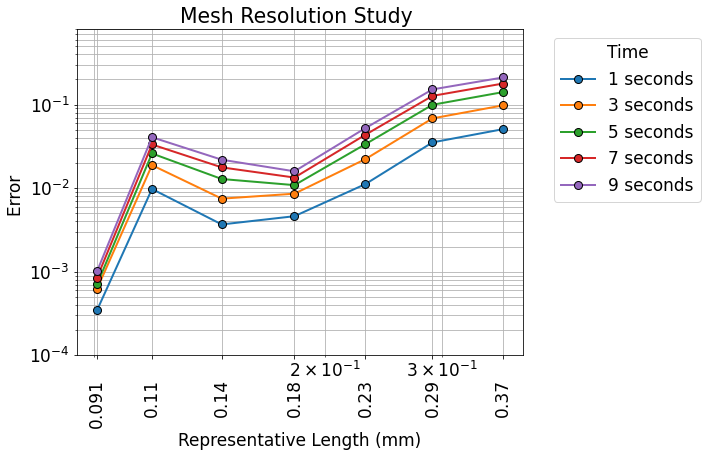

In [97]:
plt.figure(figsize=(8,6)) 
plt.title(f'Mesh Resolution Study '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('Representative Length (mm)')
plt.ylabel('Error ');
plt.grid(True, which="both",ls='-');
for i in np.arange(0,11):
    if np.mod(i, 2) != 0:
        qoi_t0 = qoiAll[i] #rich_extrap_time
        qoi_extrap = srq_extrap_times[i]
        err_t = []
        for q in qoi_t0:
            err = q - qoi_extrap
            err_t.append(np.abs(err) )
        plt.loglog(len_representative,err_t, marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i} seconds')
        print(err_t)
plt.ylim(0.0001,0.8)
plt.legend(title='Time', bbox_to_anchor=(1.05,1.0))
plt.xticks(len_representative, labels=[str(i) for i in len_representative],rotation=90)
plt.tick_params(axis='x', which='major', pad=20)
plt.savefig(f'figures/studyMeshResolution-Error_GCI.png', dpi = 300, bbox_inches='tight')

## Mesh Discretization Error 

In [148]:
errAll =[]
for i in np.arange(0,11):   #12):
    qoi_t0 = qoiAll[i] #rich_extrap_time
    qoi_extrap = srq_extrap_times[i]
    err_t = []
    for q in qoi_t0:
        err = q - qoi_extrap
        err_t.append(np.abs(err) )
    errAll.append(err_t)
#     print(err)

qoi_percent_mesh3 = []
for i in np.arange(0,11):
    for j in np.arange(0,6):
        if j == 2:
            qoi_percent_mesh3.append(errAll[i][j])    
np.max(qoi_percent_mesh3)*100 # in percent

5.692478719212257

In [46]:
# qoi_percent_mesh3

In [145]:
errAll[0]

[0.02514757137559054,
 0.0176096713756021,
 0.005463671375572354,
 0.0021352286244326057,
 0.0019236713755855783,
 0.004546028624382692,
 0.0001515286243932712]

In [35]:
# plt.figure(figsize=(8,6)) 
# plt.title(f'Mesh Resolution Study - Relative Error '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
# plt.xlabel('Mesh Elements')
# plt.ylabel('Relative Error');
# plt.grid(True, which="both",ls='-');

# for i in np.arange(1,12):   #12):
#     diff_times = []
#     if np.mod(i, 2) != 0:
#         qoi = []
#         meshElem_qoi = []
#         for f in np.arange(21,28):
#             qoi.append((df.iloc[f][columnNames_mesh12[i]])-300)
# #             diff = qoi[:]-rich_extrap_time[i]
# #             diff_times.append(diff)
#         mesh_elem = [8486,18370,36516,69736,145152,295981,578733]
# #         qoi_ext = qoi
# #         qoi.insert(0,rich_extrap_time)
# #         mesh_elem.insert(0,rich_elem_size_time)
#         plt.loglog(mesh_elem[:], np.abs(qoi[:]-srq_extrap),marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i} seconds');
# #         plt.loglog(mesh_elem[:], np.abs(qoi[:]-rich_extrap_time[i]),marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i} seconds');
# plt.xticks(rotation=45)
# plt.legend(title='Time', bbox_to_anchor=(1.05,1.0))
# #     plt.xlim(8000,)
# plt.gca().invert_xaxis()  # For reversing the x-axis
# #     plt.ylim(rangeMin[i],rangeMax[i])
# plt.savefig(f'figures/studyMeshResolution-Error_CGI.png', dpi = 300, bbox_inches='tight')
# # print(np.abs(qoi[:-1]-qoi[-1]))

## Study Time 

In [149]:
index_time   = [37,13,14,15,16] #np.arange(13,17,1)  #0.5 to 5sec by 0.5 sec
columnNames_time = columnNames(index_mesh5)
timeTime = [1,2,3,4,5]
columnNames_time
# index_mesh12   = [20,22,24,26,28,29,30,31,32,33,34,35] #1 to 12 by 1sec
# columnNames_mesh12 = columnNames(index_mesh12)
# time = np.arange(1,13,1)

['t1_r2', 't2_r2', 't3_r2', 't4_r2', 't5_r2']

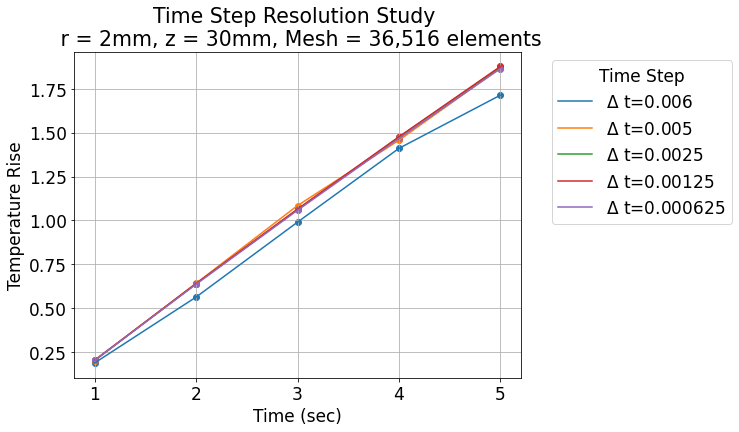

In [153]:
plt.figure(figsize=(8,6))
plt.title('Time Step Resolution Study \n r = 2mm, z = 30mm, Mesh = 36,516 elements');
plt.xlabel('Time (sec)');
plt.ylabel('Temperature Rise');
plt.grid(True, which="both",ls='-');
i = 0 
for f in index_time:
    plt.plot(timeTime,(df.iloc[f][columnNames_time])-300,label=f'$\Delta$ t={time_step[f]}');
    plt.scatter(timeTime,(df.iloc[f][columnNames_time])-300);
    i+=1
plt.legend(title='Time Step', bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studyTimeResolution_t0.005.png', dpi = 300, bbox_inches='tight')

In [154]:
index_time

[37, 13, 14, 15, 16]

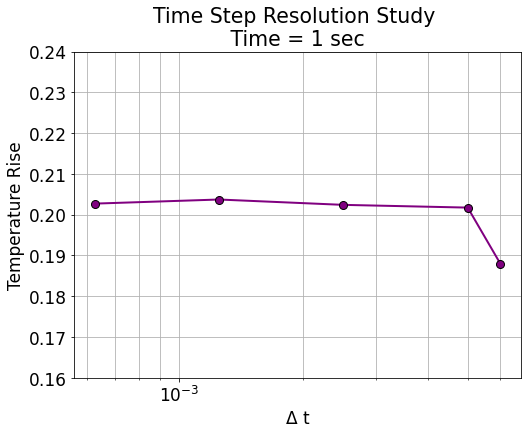

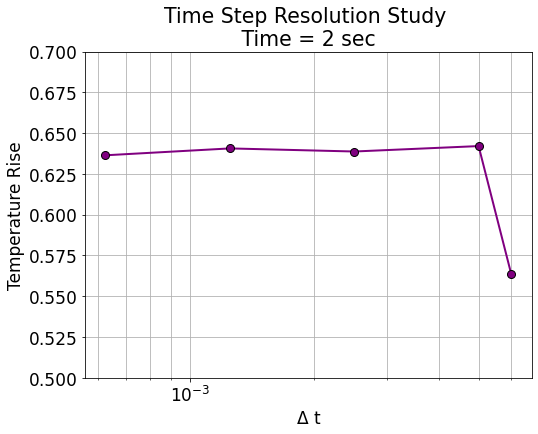

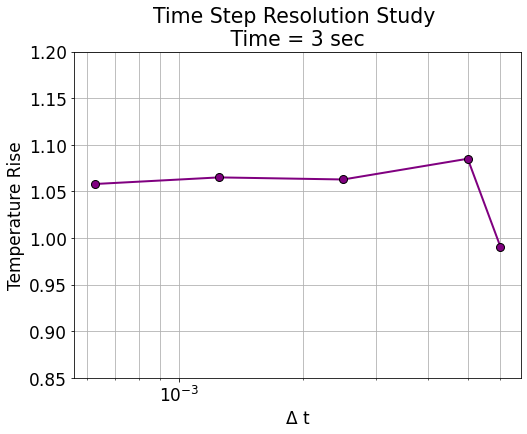

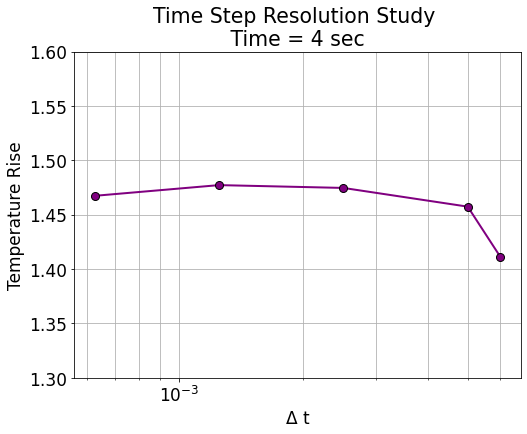

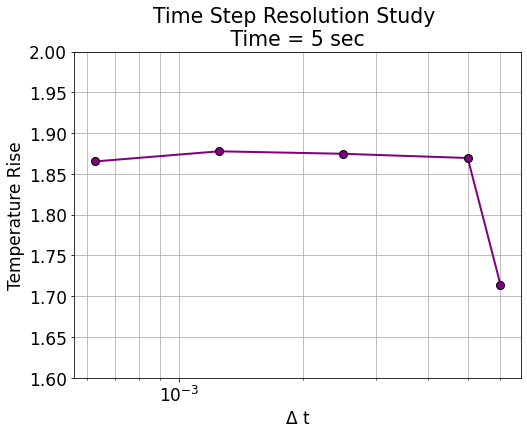

In [155]:
rangeMin = [0.16,0.5,0.85,1.3,1.6]
rangeMax = [0.24,0.7,1.20,1.6,2.0]
i = 0 
while i < len(index_mesh5):
    plt.figure(figsize=(8,6)) 
    plt.title(f'Time Step Resolution Study \n Time = {i+1} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
    plt.xlabel('$\Delta$ t');
    plt.ylabel('Temperature Rise');
    plt.grid(True, which="both",ls='-');
    qoi = []
    time_qoi = []
    for f in index_time:
        qoi.append((df.iloc[f][columnNames_time[i]])-300)
        time_qoi.append(time_step[f])
    plt.semilogx(time_qoi,qoi, color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
    plt.ylim(rangeMin[i],rangeMax[i])
    plt.savefig(f'figures/studyTimeResolution_time{i+1}.png', dpi = 300, bbox_inches='tight')
    i+=1


[0.0147706000000198 0.0009766000000013 0.0003052000000139
 0.0010070000000155]
[0.0729981000000066 0.0056457000000023 0.0023193000000106
 0.0042114000000311]
[0.0673522999999818 0.0271301000000221 0.0048828000000185
 0.0071106000000327]
[0.0562438999999699 0.0099488000000179 0.0072630999999888
 0.0098571000000334]
[0.1509398999999689 0.0042420000000334 0.0094300000000089
 0.0124817000000235]


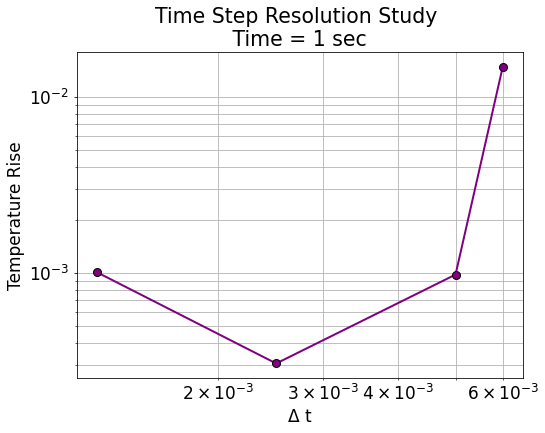

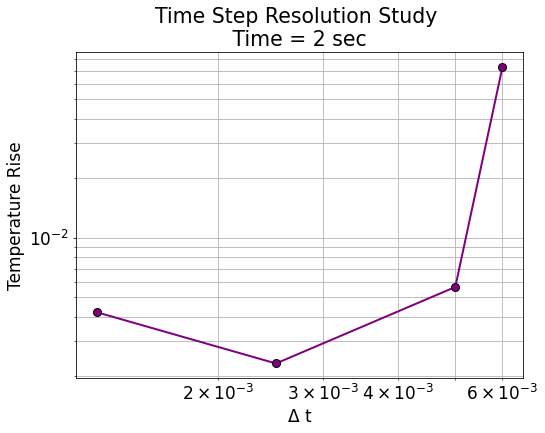

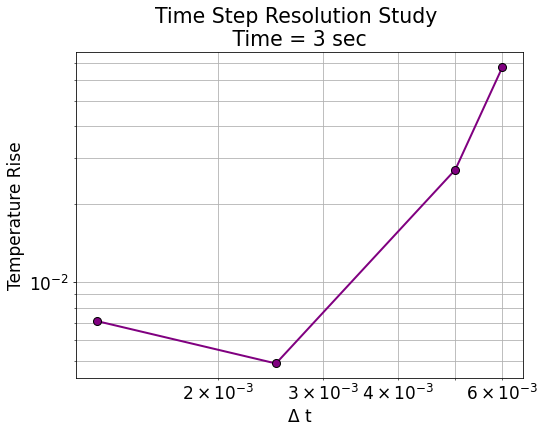

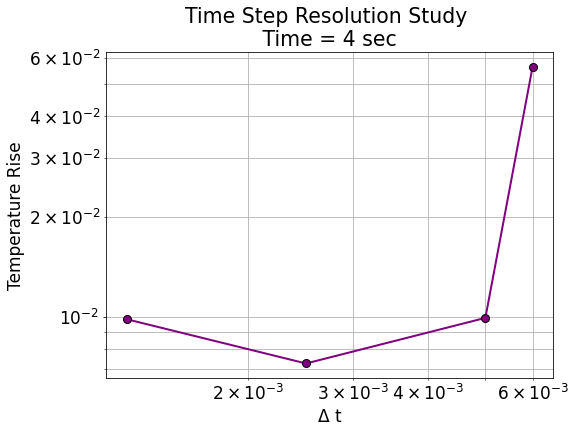

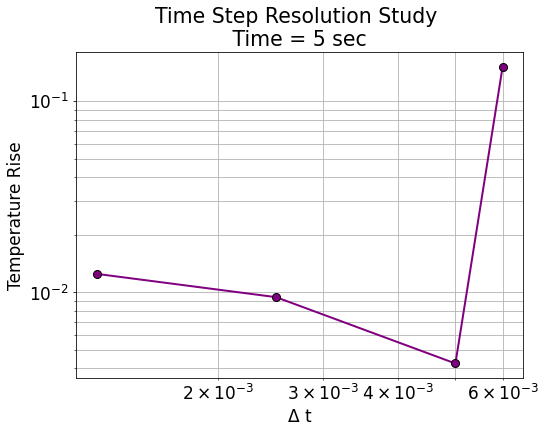

In [168]:
# rangeMin = [0.16,0.5,0.85,1.3,1.6]
# rangeMax = [0.24,0.7,1.20,1.6,2.0]
i = 0 
while i < len(index_mesh5):
    plt.figure(figsize=(8,6)) 
    plt.title(f'Time Step Resolution Study \n Time = {i+1} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
    plt.xlabel('$\Delta$ t');
    plt.ylabel('Temperature Rise');
    plt.grid(True, which="both",ls='-');
    qoi = []
    time_qoi = []
    for f in index_time:
        qoi.append((df.iloc[f][columnNames_time[i]])-300)
        time_qoi.append(time_step[f])
    plt.loglog(time_qoi[:-1],np.abs(qoi[:-1]-qoi[-1]), color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
#     plt.ylim(rangeMin[i],rangeMax[i])
    plt.savefig(f'figures/studyTimeResolution-RelativeError_time{i+1}.png', dpi = 300, bbox_inches='tight')
#     print(qoi)
    print(np.abs(qoi[:-1]-qoi[-1]))
    i+=1

In [169]:
# 1 sec = [0.18792719999999008, 0.2017212000000086, 0.20239259999999604, 0.20370480000002544, 0.20269780000000992]
# 2 sec = [0.5633849999999825, 0.6420287999999914, 0.6387023999999997, 0.6405945000000202, 0.6363830999999891]
# 3 sec = [0.9904784999999947, 1.0849608999999987, 1.062713599999995, 1.0649414000000093, 1.0578307999999765]
# 4 sec = [1.4110413000000221, 1.4573363999999742, 1.4745482999999808, 1.4771423000000254, 1.467285199999992]
# 5 sec = [1.714233400000012, 1.8694153000000142, 1.8746032999999898, 1.8776550000000043, 1.8651732999999808]

In [171]:
time_qoi[1]

0.005

In [165]:
qoiAll = [];
qoiAllDiff =[]
i=0
while i < len(index_mesh5):
    qoi = []
    time_qoi = []
    for f in index_time:
        qoi.append((df.iloc[f][columnNames_time[i]])-300)
    qoiAll.append(qoi)
    #qoiAllDiff.append(100*np.abs(qoi[:-1]-qoi[-1])/((qoi[:-1]+qoi[-1])/2))
    qoiAllDiff.append(np.abs(qoi[:-1]-qoi[-1]))
    i+=1
len(qoiAllDiff)

5

In [160]:
qoiAllDiff

[array([0.0147706000000198, 0.0009766000000013, 0.0003052000000139,
        0.0010070000000155]),
 array([0.0729981000000066, 0.0056457000000023, 0.0023193000000106,
        0.0042114000000311]),
 array([0.0673522999999818, 0.0271301000000221, 0.0048828000000185,
        0.0071106000000327]),
 array([0.0562438999999699, 0.0099488000000179, 0.0072630999999888,
        0.0098571000000334]),
 array([0.1509398999999689, 0.0042420000000334, 0.0094300000000089,
        0.0124817000000235])]

## Time step discretization error 

In [173]:
qoi_percent_t2 = []
i=0
for i in np.arange(0,5):
    for j in np.arange(0,4):
        if j == 1:
            qoi_percent_t2.append(qoiAllDiff[i][j])    
    i+=1
np.max(qoi_percent_t2)*100  # percent

2.713010000002214

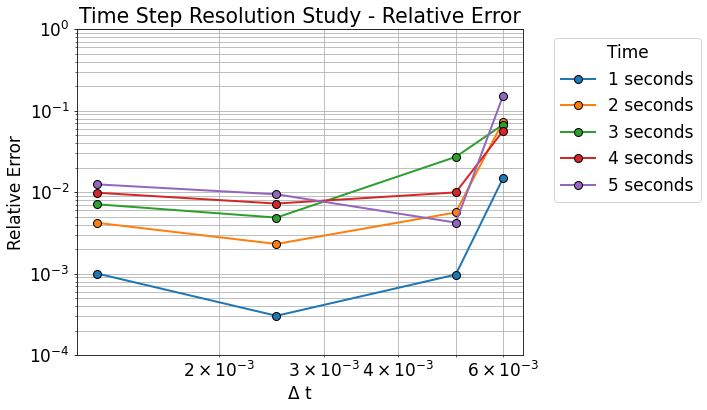

In [174]:
# rangeMin = [0.16,0.5,0.85,1.3,1.6]
# rangeMax = [0.24,0.7,1.20,1.6,2.0]
plt.figure(figsize=(8,6)) 
plt.title(f'Time Step Resolution Study - Relative Error'); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('$\Delta$ t');
plt.ylabel('Relative Error');
plt.grid(True, which="both",ls='-');
i = 0 
while i < len(index_mesh5):
    qoi = []
    time_qoi = []
    for f in index_time:
        qoi.append((df.iloc[f][columnNames_time[i]])-300)
        time_qoi.append(time_step[f])
    plt.loglog(time_qoi[:-1],np.abs(qoi[:-1]-qoi[-1]), marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i+1} seconds');
#     plt.ylim(rangeMin[i],rangeMax[i])
#     print(qoi)
# print(np.abs(qoi[:-1]-qoi[-1]))
    i+=1
plt.ylim(10**(-4), 10**(0))
plt.legend(title='Time',bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studyTimeResolution-RelativeError_timeALL.png', dpi = 300, bbox_inches='tight')


## Solver Tolerance  Study

In [175]:
index_solvTol   = np.arange(39,45,1)  
columnNames_solvTol = columnNames(index_mesh5)
timeTime = [1,2,3,4,5]
columnNames_time

['t1_r2', 't2_r2', 't3_r2', 't4_r2', 't5_r2']

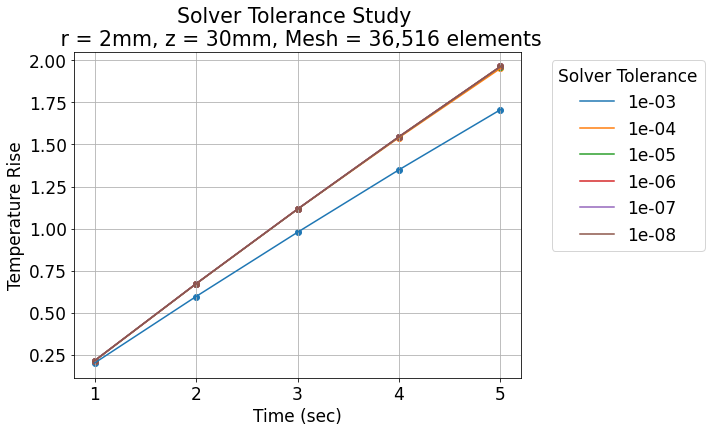

In [176]:
plt.figure(figsize=(8,6))
plt.title('Solver Tolerance Study \n r = 2mm, z = 30mm, Mesh = 36,516 elements');
plt.xlabel('Time (sec)');
plt.ylabel('Temperature Rise');
plt.grid(True, which="both",ls='-');
i = 0 
for f in index_solvTol:
    plt.plot(timeTime,(df.iloc[f][columnNames_solvTol])-300,label=(f"{solv_tol[f]:.0e}")) #label=f'{solv_tol[f]}');
    plt.scatter(timeTime,(df.iloc[f][columnNames_solvTol])-300);
    i+=1
plt.legend(title='Solver Tolerance', bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studySolverTol.png', dpi = 300, bbox_inches='tight')

[1.3580300000000989e-02 1.1292000000366897e-03 1.8310000001520166e-04
 3.0500000036681740e-05 0.0000000000000000e+00]
[7.5988800000004630e-02 1.0985999999775231e-03 4.2729999995572143e-04
 3.0499999979838321e-05 0.0000000000000000e+00]
[1.3781739999996034e-01 1.0070999999811647e-03 1.0375999999610030e-03
 1.8309999995835824e-04 3.0499999979838321e-05]
[1.9671629999999141e-01 5.3100999999742271e-03 9.4610000002148809e-04
 1.5259999997851992e-04 0.0000000000000000e+00]
[2.5701899999995703e-01 1.1413500000003296e-02 8.8499999998248313e-04
 1.5249999995603503e-04 0.0000000000000000e+00]


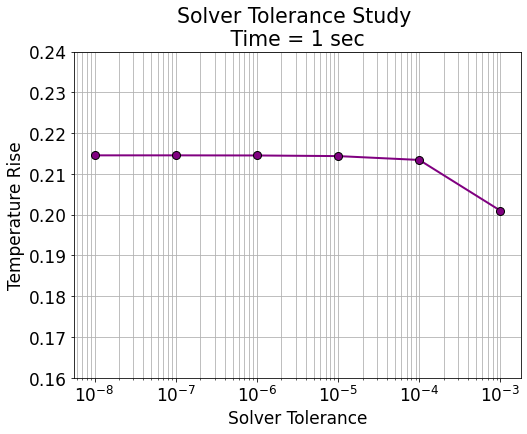

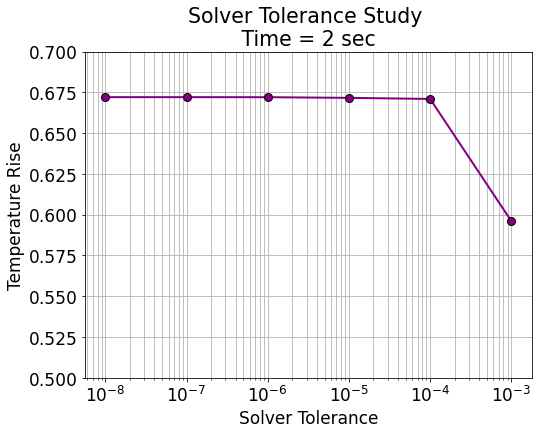

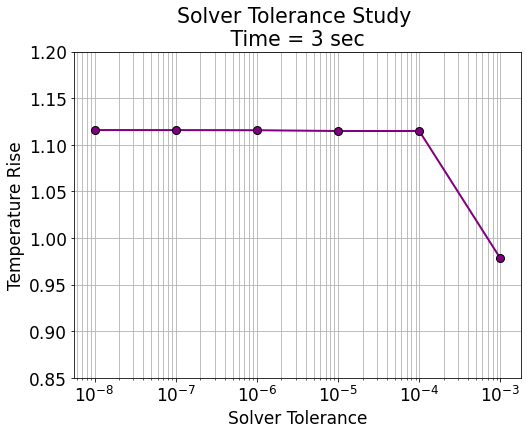

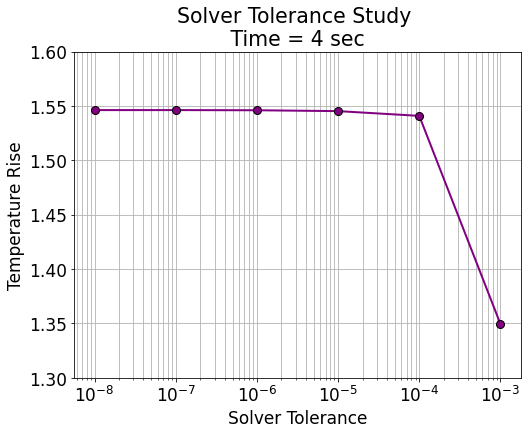

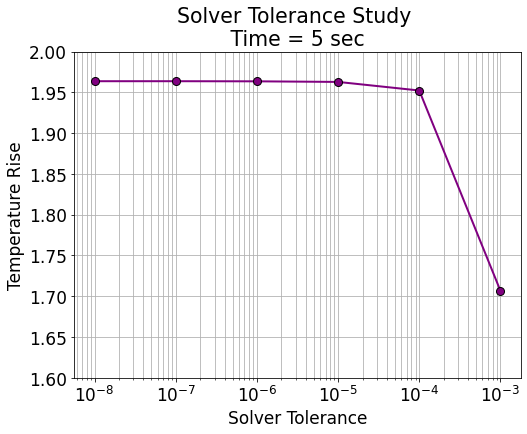

In [177]:
rangeMin = [0.16,0.5,0.85,1.3,1.6]
rangeMax = [0.24,0.7,1.20,1.6,2.0]
i = 0 
while i < len(index_mesh5):
    plt.figure(figsize=(8,6)) 
    plt.title(f'Solver Tolerance Study \n Time = {i+1} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
    plt.xlabel('Solver Tolerance');
    plt.ylabel('Temperature Rise');
    plt.grid(True, which="both",ls='-');
    qoi = []
    solvTol_qoi = []
    for f in index_solvTol:
        qoi.append((df.iloc[f][columnNames_solvTol[i]])-300)
        solvTol_qoi.append(solv_tol[f])
    plt.semilogx(solvTol_qoi,qoi, color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
    plt.ylim(rangeMin[i],rangeMax[i])
    plt.savefig(f'figures/studySolvTol_time{i+1}.png', dpi = 300, bbox_inches='tight')
#     print(qoi)
    print(np.abs(qoi[:-1]-qoi[-1]))
    i+=1

[1.3580300000000989e-02 1.1292000000366897e-03 1.8310000001520166e-04
 3.0500000036681740e-05 0.0000000000000000e+00]
[7.5988800000004630e-02 1.0985999999775231e-03 4.2729999995572143e-04
 3.0499999979838321e-05 0.0000000000000000e+00]
[1.3781739999996034e-01 1.0070999999811647e-03 1.0375999999610030e-03
 1.8309999995835824e-04 3.0499999979838321e-05]
[1.9671629999999141e-01 5.3100999999742271e-03 9.4610000002148809e-04
 1.5259999997851992e-04 0.0000000000000000e+00]
[2.5701899999995703e-01 1.1413500000003296e-02 8.8499999998248313e-04
 1.5249999995603503e-04 0.0000000000000000e+00]


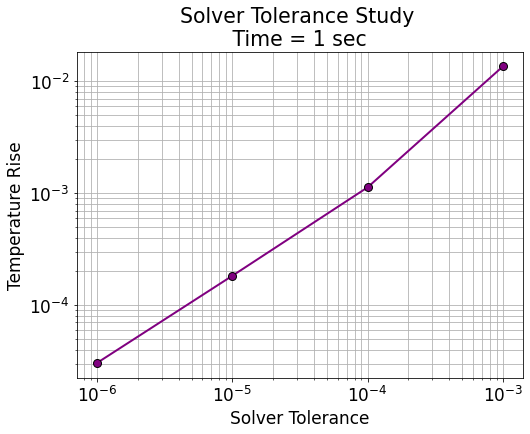

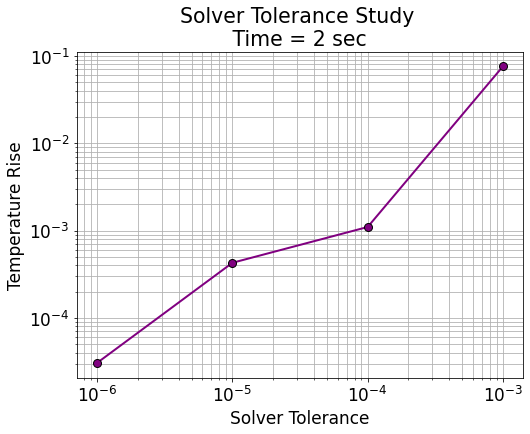

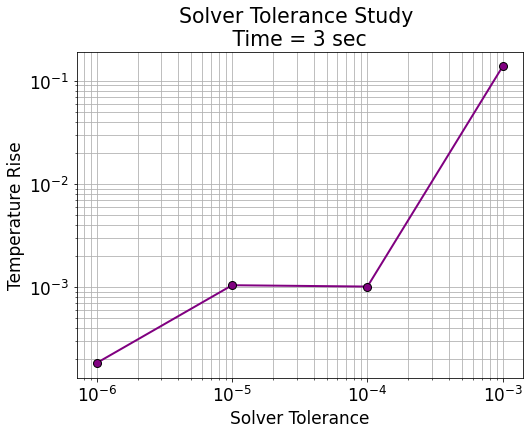

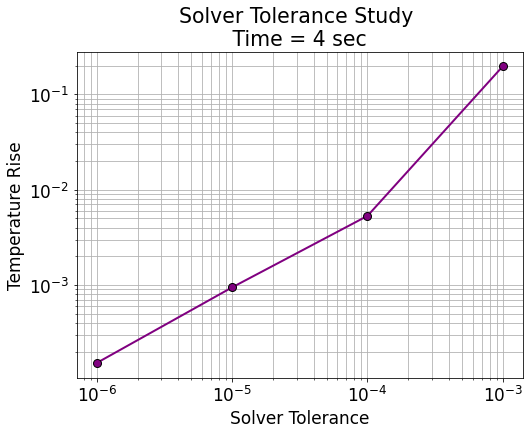

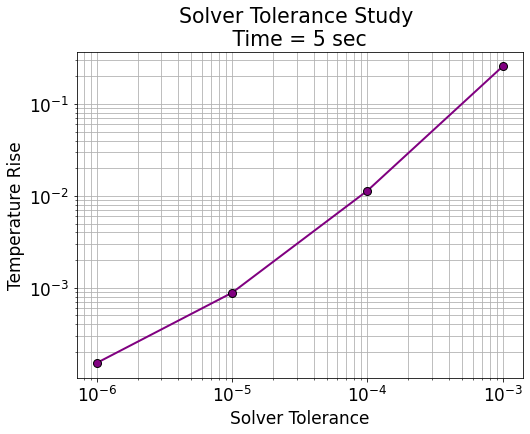

In [178]:
i = 0 
while i < len(index_mesh5):
    plt.figure(figsize=(8,6)) 
    plt.title(f'Solver Tolerance Study \n Time = {i+1} sec '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
    plt.xlabel('Solver Tolerance');
    plt.ylabel('Temperature Rise');
    plt.grid(True, which="both",ls='-');
    qoi = []
    solvTol_qoi = []
    for f in index_solvTol:
        qoi.append((df.iloc[f][columnNames_solvTol[i]])-300)
        solvTol_qoi.append(solv_tol[f])
    plt.loglog(solvTol_qoi[:-2],np.abs(qoi[:-2]-qoi[-1]), color='purple', marker='o', markersize=8, linewidth=2, markeredgecolor='black');
    plt.savefig(f'figures/studySolverTol-RelativeError_time{i+1}.png', dpi = 300, bbox_inches='tight')
    print(np.abs(qoi[:-1]-qoi[-1]))
    i+=1


In [179]:
tol_qoi = np.abs(qoi[:-1]-qoi[-1]) #solvTol_qoi[:-1]
tol_qoi

array([2.5701899999995703e-01, 1.1413500000003296e-02,
       8.8499999998248313e-04, 1.5249999995603503e-04,
       0.0000000000000000e+00])

In [180]:
qoi #solvTol_qoi 

[1.706604000000027,
 1.9522094999999808,
 1.9627380000000016,
 1.963470500000028,
 1.9636229999999841,
 1.9636229999999841]

In [181]:
# 1 sec = [1.3e-02, 1.1e-03, 1.8e-04, 3.0e-05, 0.0e+00]
# 2 sec = [7.5e-02, 1.0e-03, 4.2e-04, 3.0e-05, 0.0e+00]
# 3 sec = [1.3e-01, 1.0e-03, 1.0e-03, 1.8e-04, 3.0e-05]
# 4 sec = [1.9e-01, 5.3e-03, 9.4e-04, 1.5e-04, 0.0e+00]
# 5 sec = [2.5e-01, 1.1e-02, 8.8e-04, 1.5e-04, 0.0e+00]

In [182]:
#                  1e-3              1e-4             1e-5                1e-6                 1e-7              1e-8
# 1 sec =[0.2009583000000248, 0.2134093999999891, 0.21435550000001058, 0.2145080999999891, 0.21453860000002, 0.21453860000002]
# 2 sec =[0.5960387999999739, 0.6709290000000010, 0.67160030000002280, 0.6719970999999987, 0.67202759999997, 0.67202759999997]
# 3 sec =[0.9779358000000116, 1.1147460999999907, 1.11471560000001100, 1.1155701000000136, 1.11572269999999, 1.11575319999997]
# 4 sec =[1.3494263000000046, 1.5408325000000218, 1.54519649999997450, 1.5459900000000175, 1.54614259999999, 1.54614259999999]
# 5 sec =[1.7066040000000270, 1.9522094999999808, 1.96273800000000160, 1.9634705000000280, 1.96362299999998, 1.96362299999998]


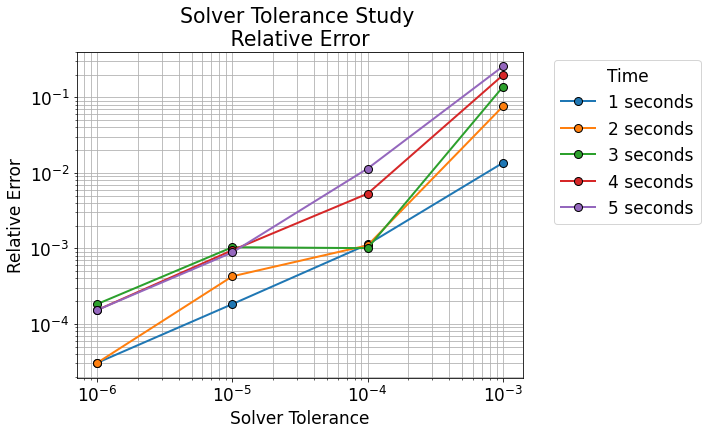

In [183]:
plt.figure(figsize=(8,6)) 
plt.title(f'Solver Tolerance Study \n Relative Error '); # \n r = 2mm, z = 30mm, \n Mesh = 36,516 elements');
plt.xlabel('Solver Tolerance');
plt.ylabel('Relative Error');
plt.grid(True, which="both",ls='-');

i = 0 
while i < len(index_mesh5):
    qoi = []
    solvTol_qoi = []
    for f in index_solvTol:
        qoi.append((df.iloc[f][columnNames_solvTol[i]])-300)
        solvTol_qoi.append(solv_tol[f])
    plt.loglog(solvTol_qoi[:-2],np.abs(qoi[:-2]-qoi[-1]),marker='o', markersize=8, linewidth=2, markeredgecolor='black', label=f'{i+1} seconds');
#     print(np.abs(qoi[:-1]-qoi[-1]))
    i+=1
plt.legend(title='Time', bbox_to_anchor=(1.05,1.0))
plt.savefig(f'figures/studySolverTol-RelativeError_timeALL.png', dpi = 300, bbox_inches='tight')


In [184]:
qoiAll = [];
qoiAllDiff =[]
i=0
while i < len(index_mesh5):
    qoi = []
    time_qoi = []
    for f in index_time:
        qoi.append((df.iloc[f][columnNames_solvTol[i]])-300)
    qoiAll.append(qoi)
    #qoiAllDiff.append(100*np.abs(qoi[:-1]-qoi[-1])/((qoi[:-1]+qoi[-1])/2))
    qoiAllDiff.append(np.abs(qoi[:-1]-qoi[-1]))
    i+=1
len(qoiAllDiff)


5

In [185]:
qoiAllDiff

[array([0.0147706000000198, 0.0009766000000013, 0.0003052000000139,
        0.0010070000000155]),
 array([0.0729981000000066, 0.0056457000000023, 0.0023193000000106,
        0.0042114000000311]),
 array([0.0673522999999818, 0.0271301000000221, 0.0048828000000185,
        0.0071106000000327]),
 array([0.0562438999999699, 0.0099488000000179, 0.0072630999999888,
        0.0098571000000334]),
 array([0.1509398999999689, 0.0042420000000334, 0.0094300000000089,
        0.0124817000000235])]

In [186]:
qoi_percent_tol6 = []
i=0
for i in np.arange(0,5):
    for j in np.arange(0,4):
        if j == 3:
            qoi_percent_tol6.append(qoiAllDiff[i][j])    
    i+=1
np.min(qoi_percent_tol6)*100

0.10070000000155233

# Computational Workload

In [187]:
# processors, clocktime (seconds)
m1_t1 = [5,23]       # Coarsest & largest t = 0.008s
m1_t5 = [18,122]     # Coarsest & smallest t = 0.000625s
m3_t2 = [5,1479]     # Middle t = 0.005s
m7_t5 = [12,11483]   # Finest & smallest t = 0.000125s
m3_t25= [9,172]

m3_t25 = [9,172]
m3_t5  = [5,100]


In [188]:
def computational_workload(processors_clockTime):
    total_time = processors_clockTime[0]*processors_clockTime[1]
    units = 'sec'
    if total_time > 60:
        total_time = total_time/60
        units = 'min'
        if total_time > 60:
            total_time = total_time/60
            units = 'hrs'
    return total_time, units

In [26]:
time_m1_t1,units_m1_t1 = computational_workload(m1_t1)
time_m1_t5,units_m1_t5 = computational_workload(m1_t5)
time_m3_t2,units_m3_t2 = computational_workload(m3_t2)
time_m7_t5,units_m7_t5 = computational_workload(m7_t5)

In [32]:
print(f'time_m1_t1 = {time_m1_t1:.0f}',units_m1_t1)
print(f'time_m1_t5 = {time_m1_t5:.0f}',units_m1_t5)
print(f'time_m3_t2 = {time_m3_t2:.0f}',units_m3_t2)
print(f'time_m7_t5 = {time_m7_t5:.0f}',units_m7_t5)

time_m1_t1 = 2 min
time_m1_t5 = 37 min
time_m3_t2 = 2 hrs
time_m7_t5 = 38 hrs
